# Forecasting Google Trends with VAR and SARIMA
Time Series Analysis - Topic #2

Author: Wiktor Kapica, 483796

Series (Google Trends, GB, monthly, 2010-2026): search interest in `"natural gas"` and `"electricity prices"`.

Idea / hypothesis. In the UK, electricity prices are set at the margin by natural gas, so attention to the two phrases should be linked. The link is plausible in both directions - gas-market stress could drive interest in electricity prices, while an electricity-bill shock could push people to search the underlying cause (gas). We let a formal Granger test decide the direction, then forecast both series with a joint VAR and two independent SARIMA models and compare out-of-sample accuracy.

Plan. (1) integration order + Granger causality; (2) VAR - specification, diagnostics, IRF, FEVD, forecast; (3) Box-Jenkins SARIMA for each series; (4) compare ex-post forecast errors; (5) conclusions.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import io, contextlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.stats.diagnostic as smd
from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests
from statsmodels.tsa.api import VAR
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.width", 160)

# Course ADF (testdf.R port): the ADF statistic is the t-ratio on the lagged level;
# a Breusch-Godfrey test on the test-regression residuals picks the number of augmentations
# (read the fewest rows where BG is no longer significant). Null = unit root (non-stationary).
def adf_test(series, max_aug=12, version="c"):
    s = pd.Series(np.asarray(series, dtype=float))
    y = s.diff()
    rows = []
    for i in range(max_aug):
        X = pd.DataFrame({"y_lag": s.shift()})
        if version in ("c", "t"):
            X = sm.add_constant(X)
        if version == "t":
            X["trend"] = range(len(X))
        for a in range(1, i + 1):
            X["aug_%d" % a] = y.shift(a)
        m = sm.OLS(y, X, missing="drop").fit()
        cv5 = {"n": -1.941, "c": -2.863, "t": -3.413}[version]   # 5% DF critical value (n > 100)
        bg = [round(smd.acorr_breusch_godfrey(m, nlags=n)[1], 3) for n in (1, 5, 10, 15)]
        rows.append([i, round(m.tvalues["y_lag"], 3), cv5] + bg)
    return pd.DataFrame(rows, columns=["augs", "ADF", "CV5%", "BGp1", "BGp5", "BGp10", "BGp15"])

# Ex-post forecast error measures (as in labs 05 and 07).
def mape(a, p):  return float(np.mean(np.abs((a - p) / a)) * 100)
def amape(a, p): return float(np.mean(np.abs((a - p) / ((a + p) / 2))) * 100)
def metrics(actual, pred):
    a = np.asarray(actual, float); p = np.asarray(pred, float)
    mse = mean_squared_error(a, p)
    return {"MAE": mean_absolute_error(a, p), "MSE": mse, "RMSE": float(np.sqrt(mse)),
            "MAPE": mape(a, p), "AMAPE": amape(a, p)}

# Per-equation Breusch-Godfrey for a VAR(p): an auxiliary OLS reproduces each VAR equation.
def var_breusch_godfrey(data, p, nlags=12):
    Y = data.values; X = []
    for t in range(p, len(Y)):
        row = [1.0]
        for j in range(1, p + 1): row.extend(Y[t - j])
        X.append(row)
    X = np.array(X); out = {}
    for i, col in enumerate(data.columns):
        res = sm.OLS(Y[p:, i], X).fit()
        out[col] = round(smd.acorr_breusch_godfrey(res, nlags=nlags)[1], 3)
    return out

## 1. Data

Google Trends returns a search-interest index scaled to [0, 100] (relative proportions preserved). Both phrases are pulled together (shared scaling) for the United Kingdom, monthly, 2010-01 - 2026-05. The pull uses `pytrends`; we save it to CSV and read the CSV so the notebook reproduces even when Google rate-limits the API (set `FETCH = True` to re-pull).

In [2]:
from pathlib import Path
FILE = "trends_naturalgas_electricityprices_GB.csv"
DATA = next((Path(d) / FILE for d in ("../data", "data") if (Path(d) / FILE).exists()), Path("../data") / FILE)

KEYWORDS = ["natural gas", "electricity prices"]
GEO, TIMEFRAME = "GB", "2010-01-01 2026-05-31"
FETCH = False   # set True to re-pull live from Google Trends (needs internet; may be rate-limited)
if FETCH:
    from pytrends.request import TrendReq
    pt = TrendReq(hl="en-US", tz=0)
    pt.build_payload(KEYWORDS, timeframe=TIMEFRAME, geo=GEO)
    pt.interest_over_time().drop(columns=["isPartial"], errors="ignore").to_csv(DATA)

df = pd.read_csv(DATA, parse_dates=["date"]).set_index("date").asfreq("MS")
df.columns = ["ng", "ep"]   # ng = "natural gas", ep = "electricity prices"
df.tail()

,ng,ep
date,,
2026-01-01,80,27
2026-02-01,91,30
2026-03-01,100,48
2026-04-01,84,44
2026-05-01,43,28


          ng     ep
count  197.0  197.0
mean    38.4   22.1
std     12.2   10.6
min     20.0   10.0
25%     30.0   15.0
50%     36.0   19.0
75%     43.0   26.0
max    100.0   78.0


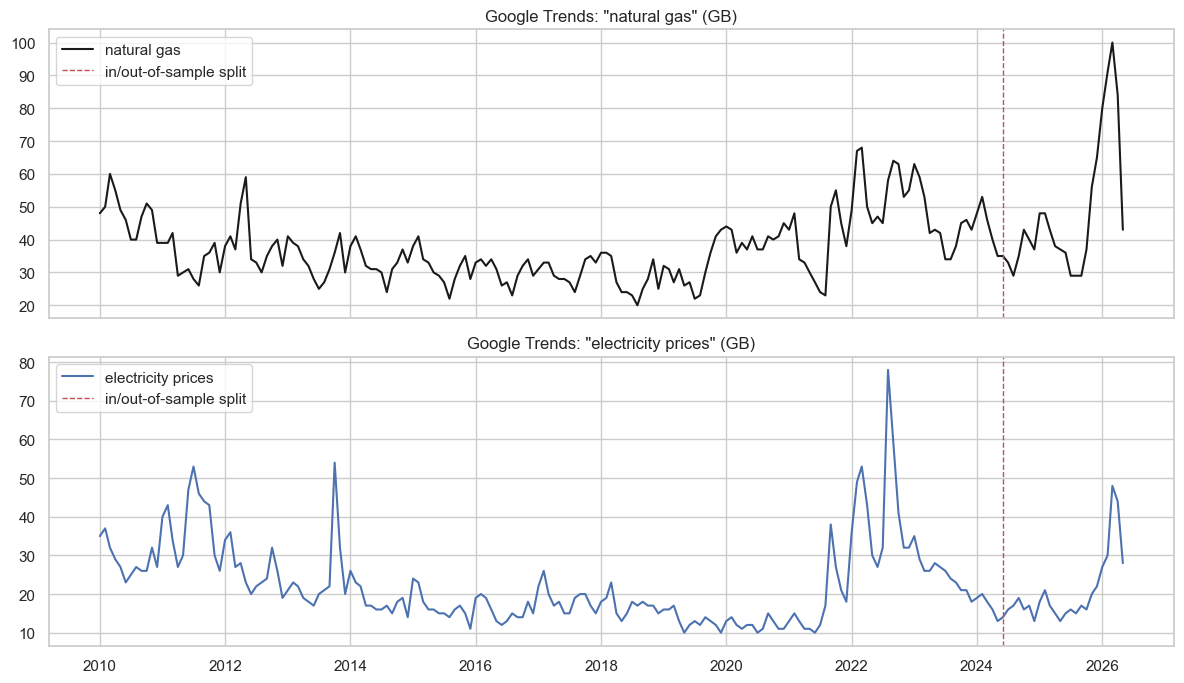

In [3]:
print(df.describe().round(1))
fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax[0].plot(df.index, df["ng"], "k-", label="natural gas"); ax[0].set_title('Google Trends: "natural gas" (GB)')
ax[1].plot(df.index, df["ep"], "b-", label="electricity prices"); ax[1].set_title('Google Trends: "electricity prices" (GB)')
for a in ax:
    a.axvline(df.index[-24], color="r", ls="--", lw=1, label="in/out-of-sample split")
    a.legend(loc="upper left")
plt.tight_layout(); plt.show()

Both series show clear annual seasonality (winter peaks) and the 2021-2023 European energy crisis; `natural gas` also has a sharp 2025/26 winter spike. We keep the last 24 months as the out-of-sample (test) window and fit every model on the first 173 observations only.

In [4]:
H = 24
ins, oos = df.iloc[:-H].asfreq("MS"), df.iloc[-H:].asfreq("MS")
ins_d = ins.diff().dropna()
print("in-sample :", ins.index.min().date(), "->", ins.index.max().date(), ins.shape)
print("out-sample:", oos.index.min().date(), "->", oos.index.max().date(), oos.shape)

in-sample : 2010-01-01 -> 2024-05-01 (173, 2)
out-sample: 2024-06-01 -> 2026-05-01 (24, 2)


## 2. Integration order and Granger causality

### 2.1 Integration order (stationarity)

We test for a unit root with the course's augmented Dickey-Fuller routine: the ADF statistic is the t-ratio on the lagged level, and a Breusch-Godfrey test on the test-regression residuals tells us how many augmentations are needed (pick the fewest rows where BG is no longer significant). ADF null = unit root (non-stationary). We confirm with `adfuller` (AIC lag choice) and KPSS (null = stationary).

In [5]:
for col in ["ng", "ep"]:
    print("\n=== %s : LEVEL ===" % col)
    print(adf_test(ins[col], 12, "c").to_string(index=False))
    print("=== %s : 1st DIFFERENCE ===" % col)
    print(adf_test(ins[col].diff().dropna(), 12, "c").to_string(index=False))


=== ng : LEVEL ===
 augs    ADF   CV5%  BGp1  BGp5  BGp10  BGp15
    0 -4.308 -2.863 0.197 0.072  0.005  0.001
    1 -4.556 -2.863 0.442 0.033  0.030  0.000
    2 -3.926 -2.863 0.316 0.697  0.192  0.002
    3 -3.312 -2.863 0.578 0.952  0.080  0.002
    4 -3.291 -2.863 0.744 0.138  0.057  0.002
    5 -3.232 -2.863 0.262 0.078  0.013  0.001
    6 -2.733 -2.863 0.314 0.256  0.014  0.005
    7 -2.408 -2.863 0.591 0.071  0.036  0.005
    8 -2.565 -2.863 0.793 0.008  0.075  0.016
    9 -2.130 -2.863 0.239 0.002  0.002  0.005
   10 -1.954 -2.863 0.488 0.001  0.003  0.001
   11 -1.729 -2.863 0.072 0.002  0.001  0.002
=== ng : 1st DIFFERENCE ===


 augs     ADF   CV5%  BGp1  BGp5  BGp10  BGp15
    0 -13.028 -2.863 0.034 0.002  0.000  0.000
    1 -11.947 -2.863 0.056 0.218  0.005  0.000
    2 -10.444 -2.863 0.760 0.609  0.008  0.001
    3  -8.105 -2.863 0.588 0.466  0.006  0.001
    4  -7.000 -2.863 0.022 0.067  0.008  0.001
    5  -7.066 -2.863 0.108 0.033  0.007  0.005
    6  -7.047 -2.863 0.821 0.036  0.029  0.007
    7  -6.047 -2.863 0.601 0.002  0.018  0.021
    8  -7.314 -2.863 0.168 0.005  0.002  0.005
    9  -7.010 -2.863 0.272 0.006  0.002  0.000
   10  -6.511 -2.863 0.124 0.009  0.001  0.001
   11  -4.307 -2.863 0.983 0.207  0.269  0.005

=== ep : LEVEL ===
 augs    ADF   CV5%  BGp1  BGp5  BGp10  BGp15
    0 -4.479 -2.863 0.320 0.001  0.001  0.004
    1 -4.618 -2.863 0.009 0.002  0.001  0.006
    2 -3.424 -2.863 0.006 0.018  0.032  0.068
    3 -2.670 -2.863 0.022 0.054  0.195  0.292
    4 -2.177 -2.863 0.733 0.279  0.504  0.649
    5 -2.033 -2.863 0.950 0.329  0.554  0.561
    6 -2.072 -2.863 0.044 0.287  0.217  0.245
 

In [6]:
for col in ["ng", "ep"]:
    for lab, s in [("level", ins[col]), ("diff", ins[col].diff())]:
        s = s.dropna()
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            adf_p, kpss_p = adfuller(s, autolag="AIC")[1], kpss(s, regression="c", nlags="auto")[1]
        print("%-4s %-5s  ADF(AIC) p=%.4f   KPSS p=%.4f" % (col, lab, adf_p, kpss_p))

ng   level  ADF(AIC) p=0.2469   KPSS p=0.0466
ng   diff   ADF(AIC) p=0.0004   KPSS p=0.1000
ep   level  ADF(AIC) p=0.2148   KPSS p=0.1000
ep   diff   ADF(AIC) p=0.0000   KPSS p=0.1000


Conclusion: both series are I(1). In levels the unit-root null is not rejected at the BG-clean specification (electricity prices: ADF ≈ -2.2 vs the -2.86 critical value; natural gas rejects only at very short augmentations, while KPSS rejects stationarity and `adfuller`/AIC does not reject). The first differences are clearly stationary under ADF, `adfuller` and KPSS. We therefore difference once: this fixes `d = 1` for the SARIMA models and means the VAR is built on first differences.

### 2.2 Granger causality

Granger causality is tested formally (not from plots) on the stationary first differences, in both directions, reading the SSR F-test p-values across lags 1-8.

In [7]:
def granger_p(data, maxlag=8):
    with contextlib.redirect_stdout(io.StringIO()):
        r = grangercausalitytests(data, maxlag=maxlag)
    return {L: round(r[L][0]["ssr_ftest"][1], 4) for L in range(1, maxlag + 1)}

d = ins[["ng", "ep"]].diff().dropna()
gt = pd.DataFrame({
    "ep -> ng  (H0: ep does NOT cause ng)": granger_p(d[["ng", "ep"]], 8),
    "ng -> ep  (H0: ng does NOT cause ep)": granger_p(d[["ep", "ng"]], 8),
})
gt.index.name = "lag"
print(gt)

     ep -> ng  (H0: ep does NOT cause ng)  ng -> ep  (H0: ng does NOT cause ep)
lag                                                                            
1                                  0.0002                                0.0362
2                                  0.0034                                0.1870
3                                  0.0173                                0.0722
4                                  0.0258                                0.1533
5                                  0.0541                                0.2940
6                                  0.0584                                0.4068
7                                  0.0208                                0.3274
8                                  0.0276                                0.1958


Conclusion: uni-directional causality, `electricity prices → natural gas`. The null "electricity prices does not cause natural gas" is rejected at 5% for lags 1-4 (p ≈ 0.0002-0.026); the reverse null is rejected only at lag 1. So interest in electricity prices helps predict interest in natural gas, but not strongly the other way round - consistent with a bill-shock story (people hit by electricity prices then look into gas, the underlying driver). The presence of Granger causality is what makes a joint VAR worthwhile: one series carries predictive information about the other.

## 3. VAR model

Why first differences. A VAR needs stationary inputs for valid inference and stable forecasts. Both series are I(1), so we model their first differences. (If they were cointegrated the right tool would be a VECM - that is Topic #1; we keep the analysis within this topic's VAR scope, modelling the first differences and reconstructing level forecasts afterwards.) Because there is Granger causality, the two equations genuinely share information.

### 3.1 Lag-order selection (information criteria)

In [8]:
print(VAR(ins_d).select_order(maxlags=15).summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        7.336      7.375*       1534.       7.352
1        7.268       7.385       1434.       7.316
2        7.199       7.394       1338.       7.278
3        7.123       7.395       1240.      7.233*
4        7.094       7.445       1206.       7.237
5        7.141       7.570       1264.       7.315
6        7.143       7.649       1267.       7.349
7        7.106       7.690       1220.       7.343
8        7.123       7.784       1242.       7.391
9        7.065       7.805       1173.       7.365
10       7.036       7.853       1140.       7.368
11       7.042       7.937       1148.       7.406
12      7.004*       7.977      1107.*       7.399
13       7.046       8.098       1157.       7.473
14       7.056       8.185       1169.       7.514
15       7.074       8.281       1193.       7.564
-------------------------------

The criteria disagree - BIC favours a very short lag, HQIC a few lags, AIC/FPE the full 12 (lag 12 = the annual cycle in monthly data). We estimate several specifications and let the residual diagnostics decide.

### 3.2 Estimate candidates and compare

In [9]:
orders = [2, 3, 12]
fits = {p: VAR(ins_d).fit(p) for p in orders}
ic = pd.DataFrame({"VAR(%d)" % p: [f.aic, f.bic, f.hqic, f.fpe] for p, f in fits.items()},
                  index=["AIC", "BIC", "HQIC", "FPE"])
print(ic.round(3))
print("\nbest by criterion:", ic.idxmin(axis=1).to_dict())

        VAR(2)    VAR(3)   VAR(12)
AIC      7.165     7.108     7.014
BIC      7.349     7.367     7.975
HQIC     7.239     7.213     7.404
FPE   1292.909  1221.951  1117.573

best by criterion: {'AIC': 'VAR(12)', 'BIC': 'VAR(2)', 'HQIC': 'VAR(3)', 'FPE': 'VAR(12)'}


In [10]:
diag = []
for p, f in fits.items():
    pt = f.test_whiteness(nlags=24, adjusted=True).pvalue
    lb = {c: round(acorr_ljungbox(f.resid[c], lags=[24], return_df=True)["lb_pvalue"].iloc[0], 3) for c in ["ng", "ep"]}
    bg = var_breusch_godfrey(ins_d, p, 12)
    diag.append(["VAR(%d)" % p, round(pt, 3), lb["ng"], lb["ep"], bg["ng"], bg["ep"],
                 round(f.test_normality().pvalue, 3)])
print(pd.DataFrame(diag, columns=["model", "Portmanteau_p", "LjungBox_ng(24)", "LjungBox_ep(24)",
                                  "BG_ng", "BG_ep", "normality_p"]).to_string(index=False))

  model  Portmanteau_p  LjungBox_ng(24)  LjungBox_ep(24)  BG_ng  BG_ep  normality_p
 VAR(2)          0.000            0.000            0.037  0.000  0.007          0.0
 VAR(3)          0.000            0.000            0.538  0.000  0.367          0.0
VAR(12)          0.433            0.956            0.991  0.005  0.547          0.0


Choosing the specification. VAR(2) and VAR(3) fail the Portmanteau test (p ≈ 0) - they leave seasonal autocorrelation in the natural-gas equation. Only VAR(12) whitens the residuals: the multivariate Portmanteau test passes (p ≈ 0.43) and Ljung-Box is clean for both series (p ≈ 0.96 / 0.99). The per-equation Breusch-Godfrey test is clean for electricity prices (p ≈ 0.55) but still flags some autocorrelation in the natural-gas equation (p ≈ 0.005); since the multivariate Portmanteau and the Ljung-Box tests - the primary tools for VAR residuals - are clean, we judge the residuals adequately white and keep VAR(12) (also selected by AIC and FPE). We accept the larger parameter count as the price of removing the seasonal autocorrelation. Residual normality is rejected - expected given the energy-crisis and 2025/26 spikes - so point forecasts stand but interval forecasts would be only approximate.

In [11]:
var = fits[12]
print(var.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 05, Jun, 2026
Time:                     16:19:46
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                    7.97474
Nobs:                     160.000    HQIC:                   7.40398
Log likelihood:          -965.161    FPE:                    1117.57
AIC:                      7.01375    Det(Omega_mle):         835.935
--------------------------------------------------------------------
Results for equation ng
            coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------
const         -0.036852         0.419656           -0.088           0.930
L1.ng         -0.185547         0.092688           -2.002           0.045
L1.ep          0.175383         0.080534            2.178           0.029
L2.ng         -0.

The summary reports one OLS equation per series. We do not read all 50 coefficients individually; what matters is that lags around the seasonal horizon (lag 12) are jointly important and that `electricity prices` lags enter the `natural gas` equation - the model-level counterpart of the Granger result. Diagnostics below confirm the fit.

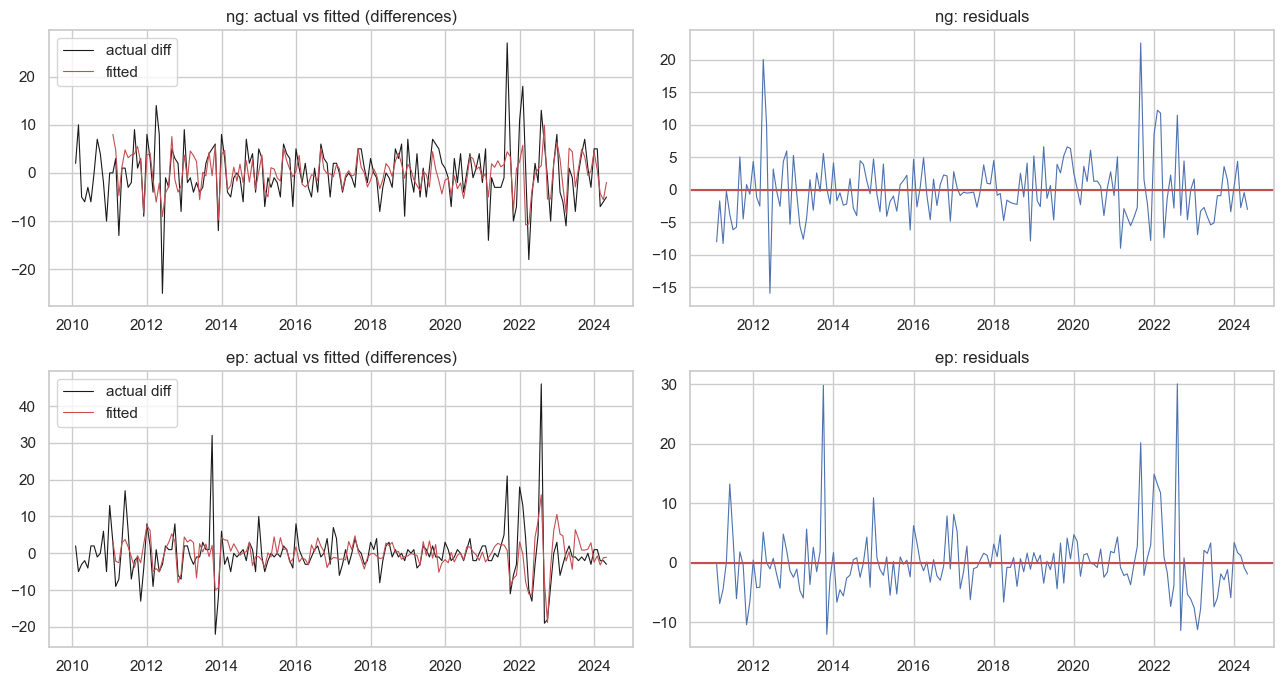

In [12]:
fig, ax = plt.subplots(2, 2, figsize=(13, 7))
for i, c in enumerate(["ng", "ep"]):
    ax[i, 0].plot(ins_d.index, ins_d[c], "k-", lw=.8, label="actual diff")
    ax[i, 0].plot(var.fittedvalues.index, var.fittedvalues[c], "r-", lw=.8, label="fitted")
    ax[i, 0].set_title("%s: actual vs fitted (differences)" % c); ax[i, 0].legend(loc="upper left")
    ax[i, 1].plot(var.resid.index, var.resid[c], "b-", lw=.8); ax[i, 1].axhline(0, color="r")
    ax[i, 1].set_title("%s: residuals" % c)
plt.tight_layout(); plt.show()

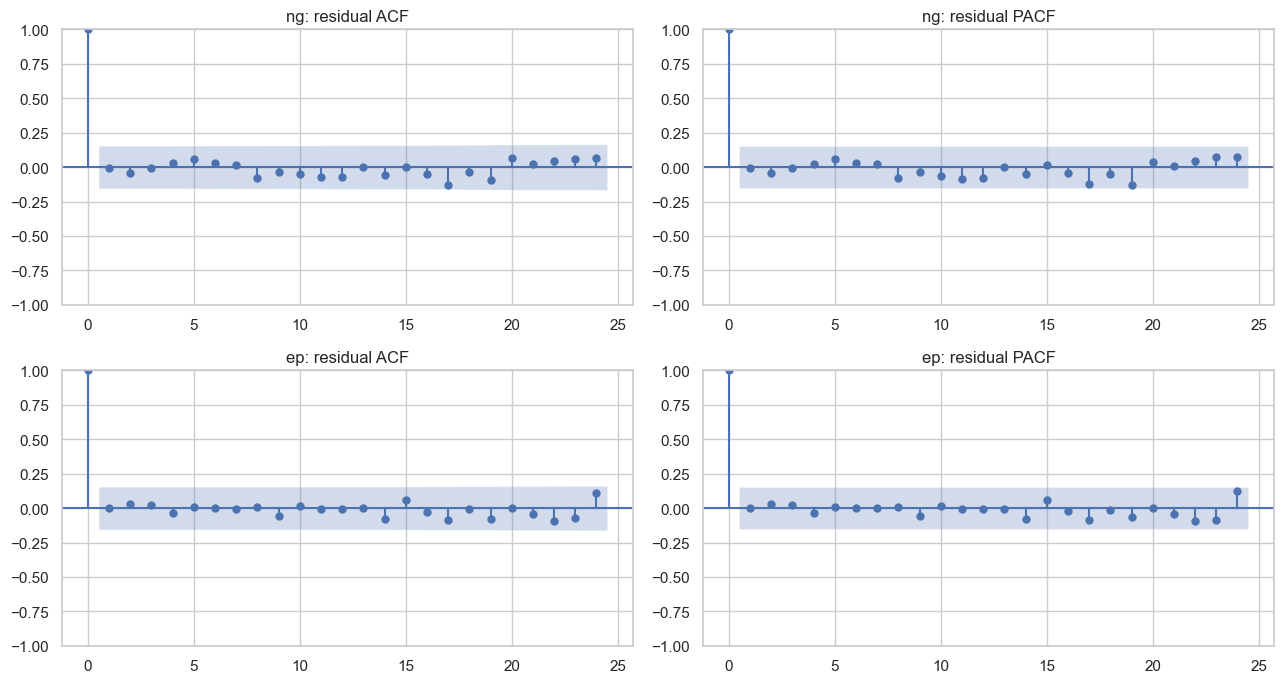

In [13]:
fig, ax = plt.subplots(2, 2, figsize=(13, 7))
for i, c in enumerate(["ng", "ep"]):
    plot_acf(var.resid[c], lags=24, ax=ax[i, 0]);                 ax[i, 0].set_title("%s: residual ACF" % c)
    plot_pacf(var.resid[c], lags=24, ax=ax[i, 1], method="ywm");  ax[i, 1].set_title("%s: residual PACF" % c)
plt.tight_layout(); plt.show()

The fitted differences track the actual differences, the residuals fluctuate around zero with no obvious pattern, and their ACF/PACF lie inside the confidence bands - consistent with the clean Portmanteau/Ljung-Box results above.

### 3.3 Impulse Response Functions

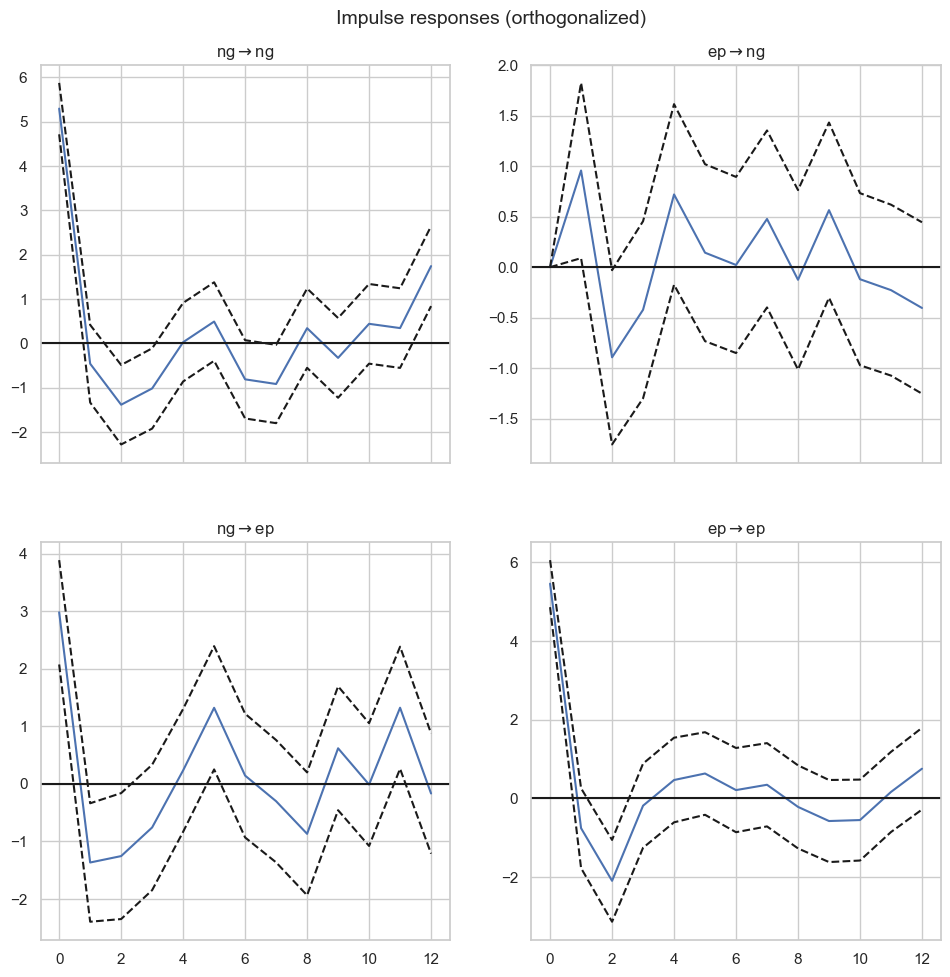

In [14]:
irf = var.irf(12)
irf.plot(orth=True)
plt.show()

The orthogonalised IRFs (Cholesky, so the ordering `natural gas, electricity prices` matters) show short-lived responses that die out within a few months, as expected for stationary differenced series. The response of `natural gas` to an `electricity prices` shock is the economically interesting one and is consistent with the Granger finding; the reverse response is weak.

### 3.4 Forecast Error Variance Decomposition

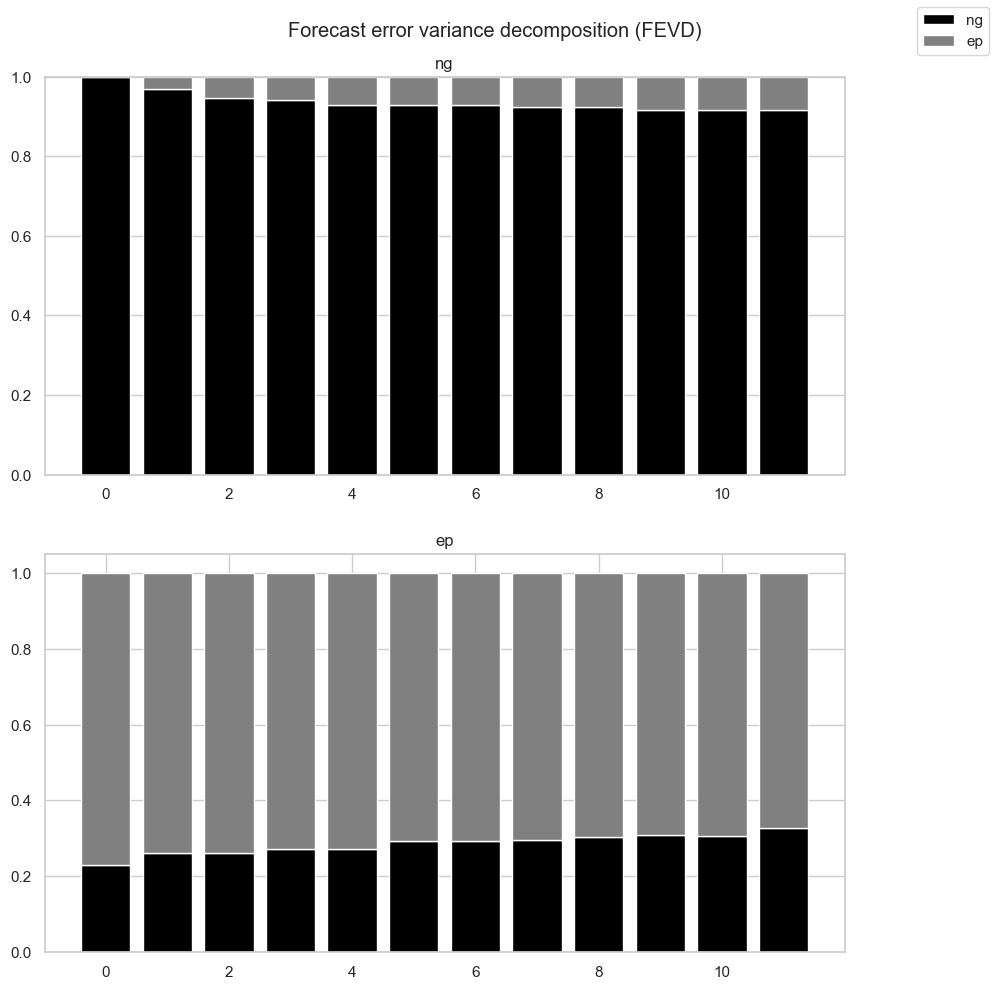

FEVD for ng
            ng        ep
0     1.000000  0.000000
1     0.968581  0.031419
2     0.946260  0.053740
3     0.942851  0.057149
4     0.928305  0.071695
5     0.928251  0.071749
6     0.929611  0.070389
7     0.925323  0.074677
8     0.925163  0.074837
9     0.917229  0.082771
10    0.917310  0.082690
11    0.916280  0.083720

FEVD for ep
            ng        ep
0     0.229550  0.770450
1     0.261426  0.738574
2     0.261770  0.738230
3     0.270500  0.729500
4     0.270101  0.729899
5     0.293338  0.706662
6     0.293365  0.706635
7     0.293965  0.706035
8     0.304139  0.695861
9     0.307278  0.692722
10    0.305481  0.694519
11    0.327795  0.672205




In [15]:
fevd = var.fevd(12)
fevd.plot()
plt.show()
fevd.summary()

Most of the forecast-error variance of `natural gas` comes from its own shocks (~90%+); for `electricity prices` a larger share (~23-33%) is attributed to `natural gas`, partly an artefact of the Cholesky ordering (gas ordered first absorbs the contemporaneous correlation). The series are linked but each is driven mostly by its own innovations.

### 3.5 Forecast and ex-post errors

We forecast the 24 differenced steps, cumulate them back onto the last in-sample level, and compare with the actual out-of-sample levels.

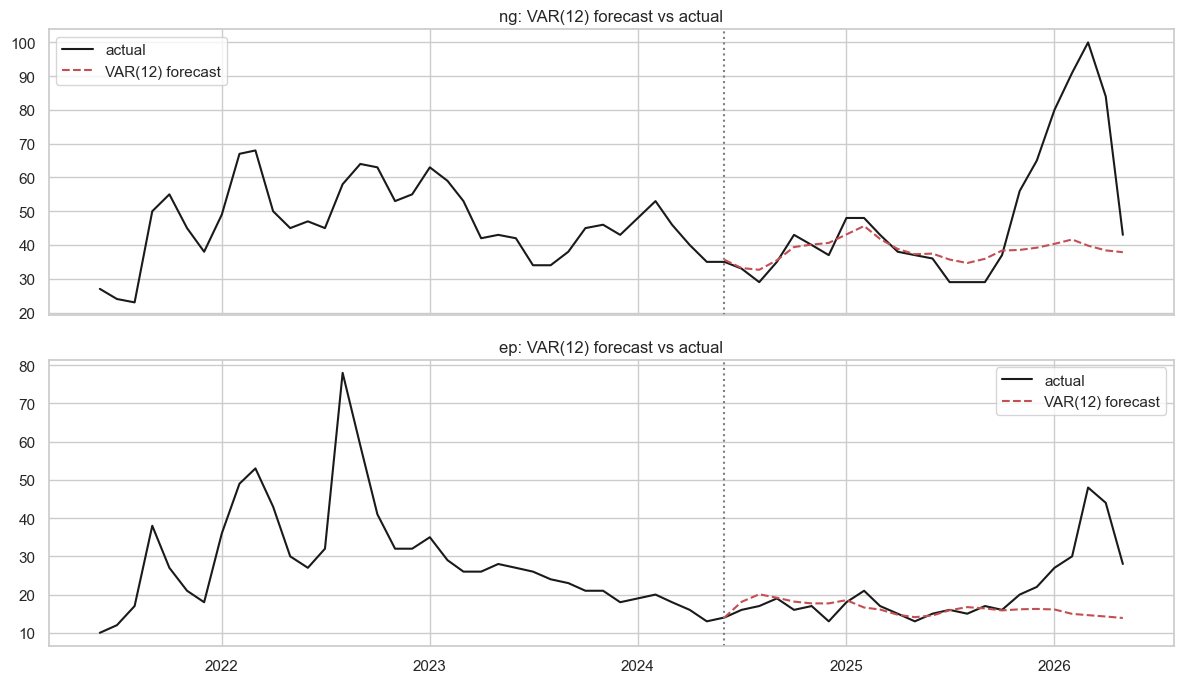

In [16]:
fc_d = pd.DataFrame(var.forecast(ins_d.values, steps=H), index=oos.index, columns=["ng", "ep"])
fc_lvl = fc_d.cumsum() + ins.iloc[-1]   # reconstruct levels from the last in-sample level

fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for i, c in enumerate(["ng", "ep"]):
    hist = df[c].iloc[-(H + 36):]
    ax[i].plot(hist.index, hist, "k-", label="actual")
    ax[i].plot(fc_lvl.index, fc_lvl[c], "r--", label="VAR(12) forecast")
    ax[i].axvline(df.index[-H], color="grey", ls=":"); ax[i].set_title("%s: VAR(12) forecast vs actual" % c)
    ax[i].legend()
plt.tight_layout(); plt.show()

In [17]:
var_metrics = {c: metrics(oos[c].values, fc_lvl[c].values) for c in ["ng", "ep"]}
print(pd.DataFrame(var_metrics).round(3))

            ng       ep
MAE     11.963    5.666
MSE    454.680  110.752
RMSE    21.323   10.524
MAPE    17.946   19.533
AMAPE   21.782   24.305


The VAR tracks the general level but, like any model, misses the sharp 2025/26 winter spike in natural gas, which inflates the errors.

## 4. SARIMA models (Box-Jenkins)

For each series separately we follow Box-Jenkins: identify orders from the ACF/PACF of the differenced series, estimate several candidates, compare on AIC/BIC, check residuals with the Ljung-Box test, and forecast. From section 2 we use `d = 1`; the monthly seasonal period is `s = 12`.

### 4.1 Natural gas - identification

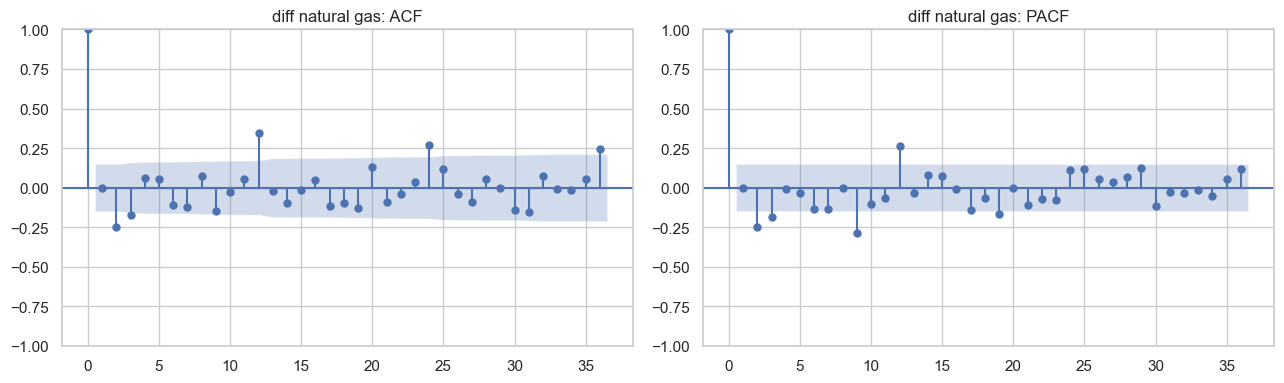

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(ins["ng"].diff().dropna(), lags=36, ax=ax[0]);                ax[0].set_title("diff natural gas: ACF")
plot_pacf(ins["ng"].diff().dropna(), lags=36, ax=ax[1], method="ywm"); ax[1].set_title("diff natural gas: PACF")
plt.tight_layout(); plt.show()

The differenced series has clear spikes at lags 12 and 24 (annual seasonality) plus small low-order terms. This points to a seasonal model: a seasonal difference (`D = 1`) with a seasonal MA term, and a low-order non-seasonal part.

In [19]:
def sarima_table(series, cands):
    rows = {}
    for order, sorder in cands:
        r = ARIMA(series, order=order, seasonal_order=sorder).fit()
        lb = acorr_ljungbox(r.resid, lags=[12, 24, 36], return_df=True)["lb_pvalue"].min()
        rows["%sx%s" % (order, sorder)] = [round(r.aic, 2), round(r.bic, 2), round(lb, 3)]
    return pd.DataFrame(rows, index=["AIC", "BIC", "LjungBox_min_p"]).T.sort_values("AIC")

ng_cands = [((0,1,2),(0,1,1,12)), ((1,1,1),(0,1,1,12)), ((0,1,1),(0,1,1,12)),
            ((1,1,0),(0,1,1,12)), ((0,1,1),(0,0,0,0)), ((1,1,0),(0,0,0,0))]
print(sarima_table(ins["ng"], ng_cands))

                             AIC      BIC  LjungBox_min_p
(0, 1, 2)x(0, 1, 1, 12)   989.46  1001.76           0.122
(1, 1, 1)x(0, 1, 1, 12)   994.43  1006.73           0.190
(0, 1, 1)x(0, 1, 1, 12)  1003.18  1012.40           0.094
(1, 1, 0)x(0, 1, 1, 12)  1005.61  1014.84           0.213
(0, 1, 1)x(0, 0, 0, 0)   1112.40  1118.70           0.000
(1, 1, 0)x(0, 0, 0, 0)   1112.40  1118.70           0.000


Best model: SARIMA(0,1,2)(0,1,1,12) - lowest AIC and BIC and clean Ljung-Box residuals. The purely non-seasonal models are strongly rejected by Ljung-Box, confirming the seasonal structure is essential.

                                     SARIMAX Results                                      
Dep. Variable:                                 ng   No. Observations:                  173
Model:             ARIMA(0, 1, 2)x(0, 1, [1], 12)   Log Likelihood                -490.730
Date:                            Fri, 05 Jun 2026   AIC                            989.461
Time:                                    16:19:50   BIC                           1001.761
Sample:                                01-01-2010   HQIC                           994.456
                                     - 05-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2024      0.059     -3.457      0.001      -0.317      -0.088
ma.L2         -0.2947      0.062   

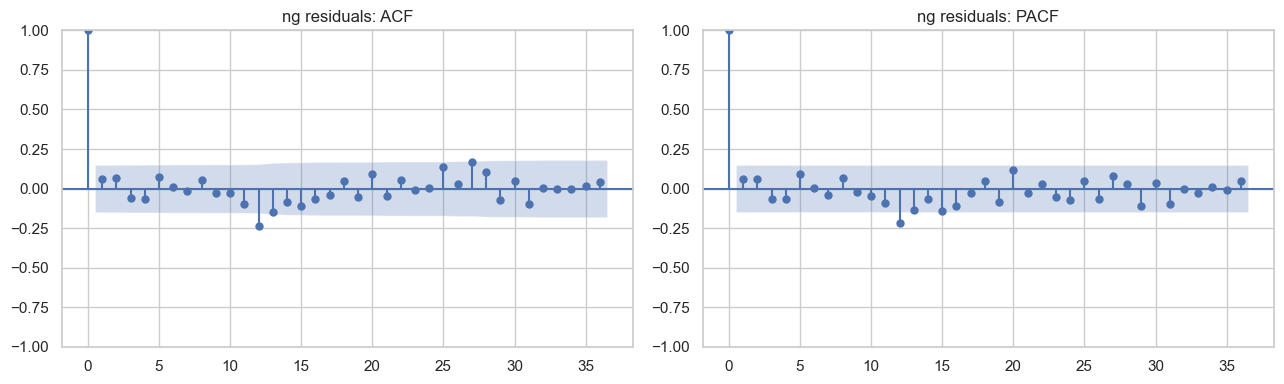

In [20]:
ng_model = ARIMA(ins["ng"], order=(0,1,2), seasonal_order=(0,1,1,12)).fit()
print(ng_model.summary())
print(acorr_ljungbox(ng_model.resid, lags=[12, 24, 36], return_df=True))
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(ng_model.resid, lags=36, ax=ax[0]);                ax[0].set_title("ng residuals: ACF")
plot_pacf(ng_model.resid, lags=36, ax=ax[1], method="ywm"); ax[1].set_title("ng residuals: PACF")
plt.tight_layout(); plt.show()

Coefficients are significant, residual ACF/PACF stay within the bands, and the Ljung-Box p-values are above 5% at all tested lags - the model is adequate. The estimated seasonal MA coefficients (≈ -0.78 and ≈ -0.88) are invertible (inside the unit circle), and the seasonal specification is strongly preferred by AIC/BIC with clean residuals, so the seasonal difference `D = 1` is justified.

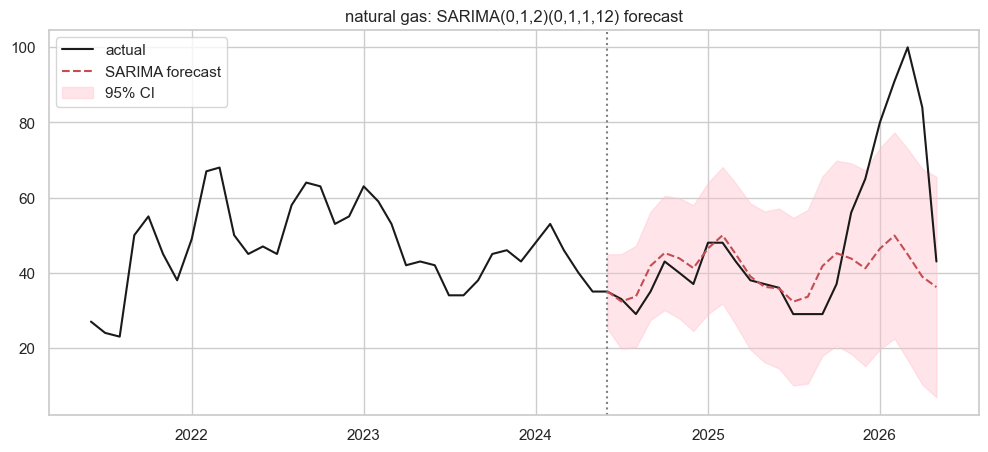

MAE       11.525
MSE      376.240
RMSE      19.397
MAPE      18.541
AMAPE     21.081
dtype: float64


In [21]:
fc = ng_model.get_forecast(steps=H); ng_fc = np.asarray(fc.predicted_mean); ci = np.asarray(fc.conf_int())
fig, ax = plt.subplots(figsize=(12, 5))
hist = df["ng"].iloc[-(H + 36):]
ax.plot(hist.index, hist, "k-", label="actual")
ax.plot(oos.index, ng_fc, "r--", label="SARIMA forecast")
ax.fill_between(oos.index, ci[:, 0], ci[:, 1], color="pink", alpha=.4, label="95% CI")
ax.axvline(df.index[-H], color="grey", ls=":"); ax.set_title("natural gas: SARIMA(0,1,2)(0,1,1,12) forecast"); ax.legend()
plt.show()
sarima_ng = metrics(oos["ng"].values, ng_fc)
print(pd.Series(sarima_ng).round(3))

### 4.2 Electricity prices - identification

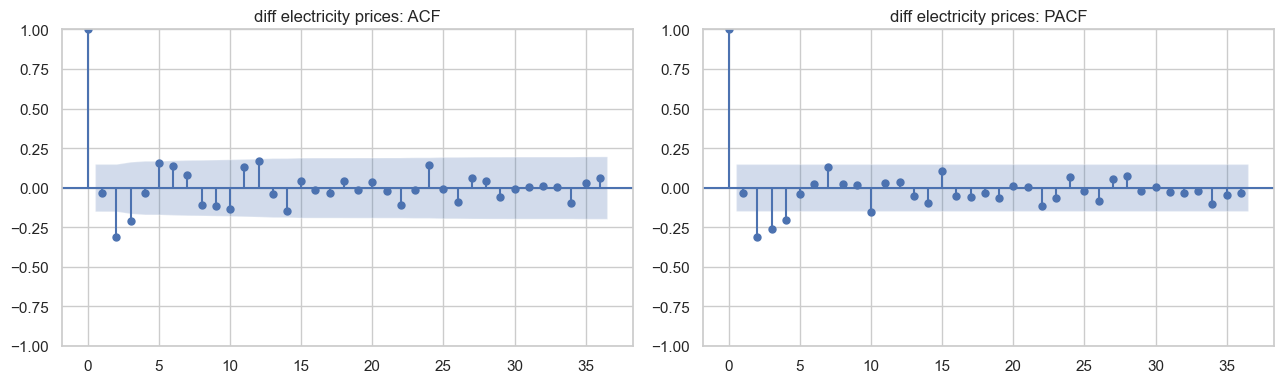

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(ins["ep"].diff().dropna(), lags=36, ax=ax[0]);                ax[0].set_title("diff electricity prices: ACF")
plot_pacf(ins["ep"].diff().dropna(), lags=36, ax=ax[1], method="ywm"); ax[1].set_title("diff electricity prices: PACF")
plt.tight_layout(); plt.show()

The differenced series shows a strong negative spike at lags 2-3 (an MA signature) and weaker seasonal structure than natural gas. We compare non-seasonal MA/AR specifications against seasonal ones.

In [23]:
ep_cands = [((0,1,2),(0,1,1,12)), ((0,1,2),(0,0,1,12)), ((0,1,2),(0,0,0,0)),
            ((1,1,1),(0,0,0,0)), ((2,1,0),(0,0,0,0)), ((0,1,1),(0,0,0,0))]
print(sarima_table(ins["ep"], ep_cands))

                             AIC      BIC  LjungBox_min_p
(0, 1, 2)x(0, 1, 1, 12)  1070.30  1082.60           0.837
(0, 1, 2)x(0, 0, 0, 0)   1131.92  1141.36           0.113
(0, 1, 2)x(0, 0, 1, 12)  1132.67  1145.26           0.266
(1, 1, 1)x(0, 0, 0, 0)   1140.94  1150.38           0.002
(2, 1, 0)x(0, 0, 0, 0)   1141.42  1150.87           0.004
(0, 1, 1)x(0, 0, 0, 0)   1156.50  1162.80           0.000


Best model: SARIMA(0,1,2)(0,1,1,12). Although the seasonal pattern looked weaker in the ACF, adding the seasonal difference and seasonal MA term sharply lowers AIC/BIC and gives the cleanest residuals - so the data prefer the seasonal model here too.

                                     SARIMAX Results                                      
Dep. Variable:                                 ep   No. Observations:                  173
Model:             ARIMA(0, 1, 2)x(0, 1, [1], 12)   Log Likelihood                -531.151
Date:                            Fri, 05 Jun 2026   AIC                           1070.301
Time:                                    16:19:52   BIC                           1082.602
Sample:                                01-01-2010   HQIC                          1075.296
                                     - 05-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2064      0.055     -3.760      0.000      -0.314      -0.099
ma.L2         -0.2993      0.080   

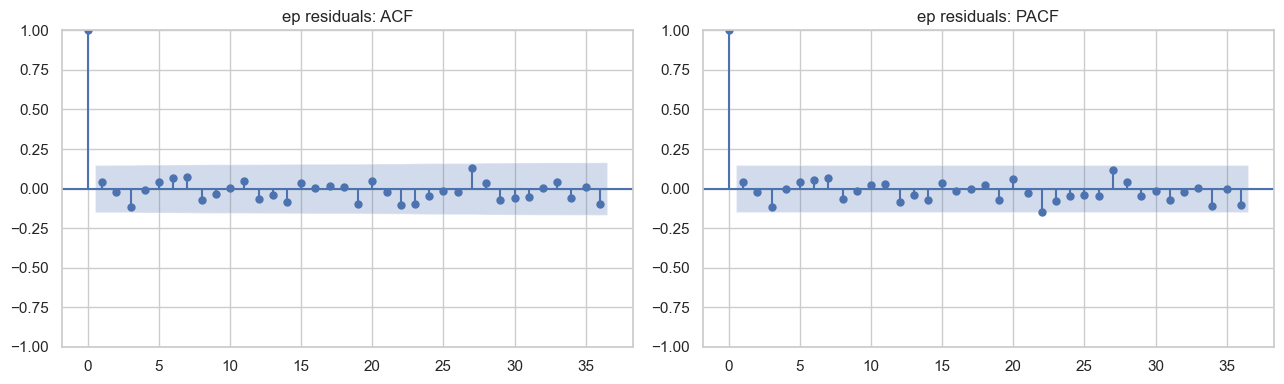

In [24]:
ep_model = ARIMA(ins["ep"], order=(0,1,2), seasonal_order=(0,1,1,12)).fit()
print(ep_model.summary())
print(acorr_ljungbox(ep_model.resid, lags=[12, 24, 36], return_df=True))
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(ep_model.resid, lags=36, ax=ax[0]);                ax[0].set_title("ep residuals: ACF")
plot_pacf(ep_model.resid, lags=36, ax=ax[1], method="ywm"); ax[1].set_title("ep residuals: PACF")
plt.tight_layout(); plt.show()

Residuals are clean (Ljung-Box p-values above 5%), so the model is adequate.

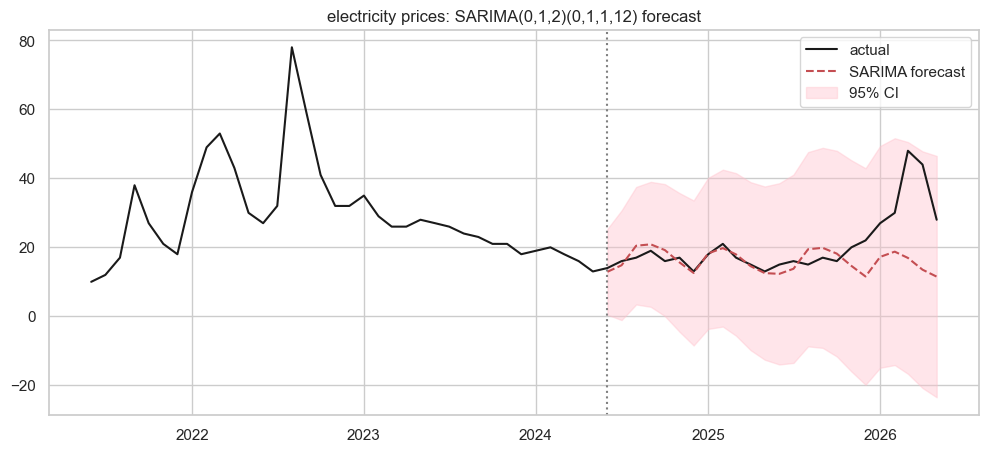

MAE        6.054
MSE      108.593
RMSE      10.421
MAPE      22.056
AMAPE     27.132
dtype: float64


In [25]:
fc = ep_model.get_forecast(steps=H); ep_fc = np.asarray(fc.predicted_mean); ci = np.asarray(fc.conf_int())
fig, ax = plt.subplots(figsize=(12, 5))
hist = df["ep"].iloc[-(H + 36):]
ax.plot(hist.index, hist, "k-", label="actual")
ax.plot(oos.index, ep_fc, "r--", label="SARIMA forecast")
ax.fill_between(oos.index, ci[:, 0], ci[:, 1], color="pink", alpha=.4, label="95% CI")
ax.axvline(df.index[-H], color="grey", ls=":"); ax.set_title("electricity prices: SARIMA(0,1,2)(0,1,1,12) forecast"); ax.legend()
plt.show()
sarima_ep = metrics(oos["ep"].values, ep_fc)
print(pd.Series(sarima_ep).round(3))

## 5. VAR vs SARIMA - forecast comparison

Same out-of-sample window (last 24 months), same five ex-post error measures, on the level scale.

In [26]:
def side(c, sarima_m):
    return pd.DataFrame({"VAR(12)": var_metrics[c], "SARIMA": sarima_m},
                        index=["MAE", "MSE", "RMSE", "MAPE", "AMAPE"])
print("natural gas\n", side("ng", sarima_ng).round(3), "\n")
print("electricity prices\n", side("ep", sarima_ep).round(3))

natural gas
        VAR(12)   SARIMA
MAE     11.963   11.525
MSE    454.680  376.240
RMSE    21.323   19.397
MAPE    17.946   18.541
AMAPE   21.782   21.081 

electricity prices
        VAR(12)   SARIMA
MAE      5.666    6.054
MSE    110.752  108.593
RMSE    10.524   10.421
MAPE    19.533   22.056
AMAPE   24.305   27.132


Reading the table. No model dominates. For natural gas the univariate SARIMA is the better forecaster (lower MAE, MSE, RMSE and AMAPE; the VAR is marginally lower only on MAPE). For electricity prices the two are essentially tied - the VAR has the lower MAE/MAPE/AMAPE, the SARIMA the lower MSE/RMSE. So the Granger causality from electricity prices to natural gas did not translate into a forecasting edge for the joint VAR - even for natural gas the simpler seasonal SARIMA wins. This is a common and important result: in-sample causality does not guarantee out-of-sample forecasting gains, especially when an unusual event (the 2025/26 winter spike) dominates the test window and hurts both models.

## 6. Conclusions

- Both Google Trends series (`"natural gas"`, `"electricity prices"`, GB, monthly) are I(1) with strong annual seasonality.
- There is uni-directional Granger causality from electricity prices to natural gas: attention to electricity prices leads attention to natural gas.
- A VAR(12) in first differences is needed to remove the seasonal autocorrelation; SARIMA(0,1,2)(0,1,1,12) fits each series well.
- Out of sample, no model dominates: SARIMA is the better forecaster for natural gas, while for electricity prices the two are essentially tied. The Granger causality did not give the VAR a forecasting edge. Both models miss the sharp 2025/26 winter spike, which dominates the errors.
- Limitations: the series are a search-interest index, not prices; the models are Gaussian and unaware of the [0, 100] bound, so forecast intervals can dip below 0 (visible for electricity prices) even though the point forecasts are unaffected; and the out-of-sample window contains an unusually sharp winter spike that no past-only model can anticipate.

Why this is useful. Search interest is a free, timely proxy for public attention to energy costs. The lead from "electricity prices" to "natural gas", together with the strong seasonality, is a simple attention/nowcast signal around the UK gas and power markets (e.g. NBP gas, utilities) - a complement to price data, not a price forecast in itself.